# **MÓDULO 32 - Exercício**
# Random Forest


Nesta tarefa, vocês vão trabalhar com uma base de dados de avaliações de vinhos, onde o objetivo é prever a pontuação dos vinhos usando o algoritmo de Random Forest para classificação multiclasse.

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [25]:
df = pd.read_csv("winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


Esta abordagem permitirá que vocês explorem como diferentes características químicas influenciam a qualidade dos vinhos e como o Random Forest pode ser usado para fazer previsões precisas com base nesses dados.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [26]:
#seu código aqui
# A)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [27]:
#B)
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

**O dataset possui apenas dados numéricos e nenhum dado nulo ou faltante portanto não foi necessário o tratamento**

# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

B) Verifique o balanceamento da váriavel Target.

C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)


# A

In [28]:
#seu código aqui
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


**Aqui podemos perceber que residual sugar apresenta valores com grande variabilidade, o alcohol está apresentando valores de 8.4 até 14.9 variando bastante e total sulfur dioxide também apresentando valores bem dispersos com valores minimos de 6.0 até 289**

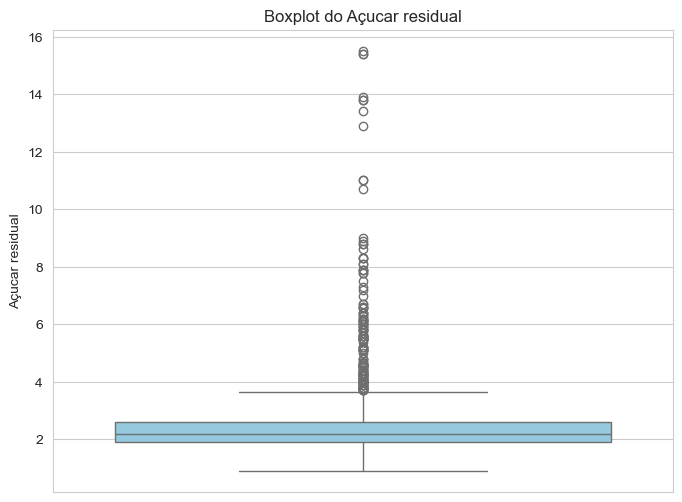

In [29]:
# verificando outliers
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='residual sugar', color='skyblue')
plt.title('Boxplot do Açucar residual')
plt.ylabel('Açucar residual')
plt.show()

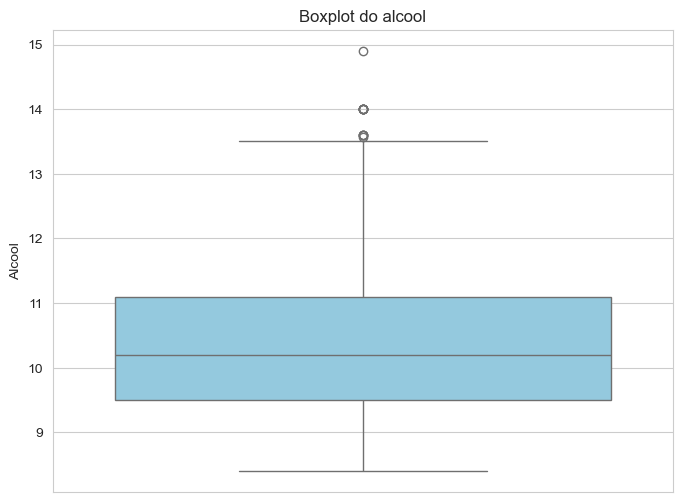

In [30]:
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='alcohol', color='skyblue')
plt.title('Boxplot do alcool')
plt.ylabel('Alcool')
plt.show()

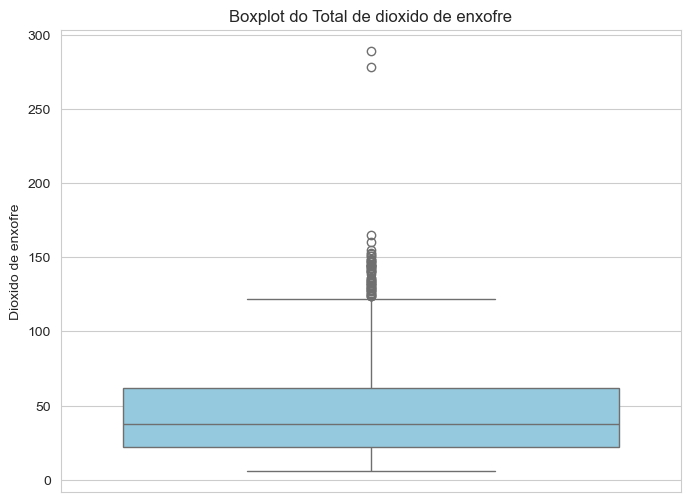

In [31]:
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='total sulfur dioxide', color='skyblue')
plt.title('Boxplot do Total de dioxido de enxofre')
plt.ylabel('Dioxido de enxofre')
plt.show()

In [32]:
# Percebendo que alcool, dioxidod e enxofre e açucar residual possuem outliers vamos ao trtamento

colunas = ['residual sugar', 'total sulfur dioxide','alcohol']

# Tratar outliers
for col in colunas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

#Salvando o df agora sem os outliers
df.to_csv('wine_sem_outliers.csv')

# B

In [33]:
df = pd.read_csv('wine_sem_outliers.csv')

df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

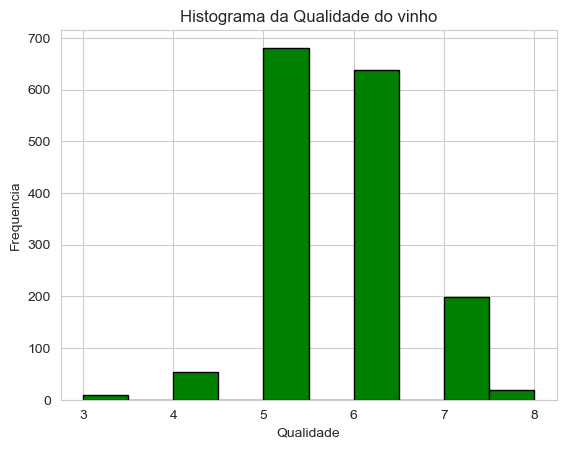

In [34]:
plt.hist(df['quality'], color='green', edgecolor='black')

plt.title('Histograma da Qualidade do vinho')
plt.xlabel('Qualidade')
plt.ylabel('Frequencia')
plt.show()

# C

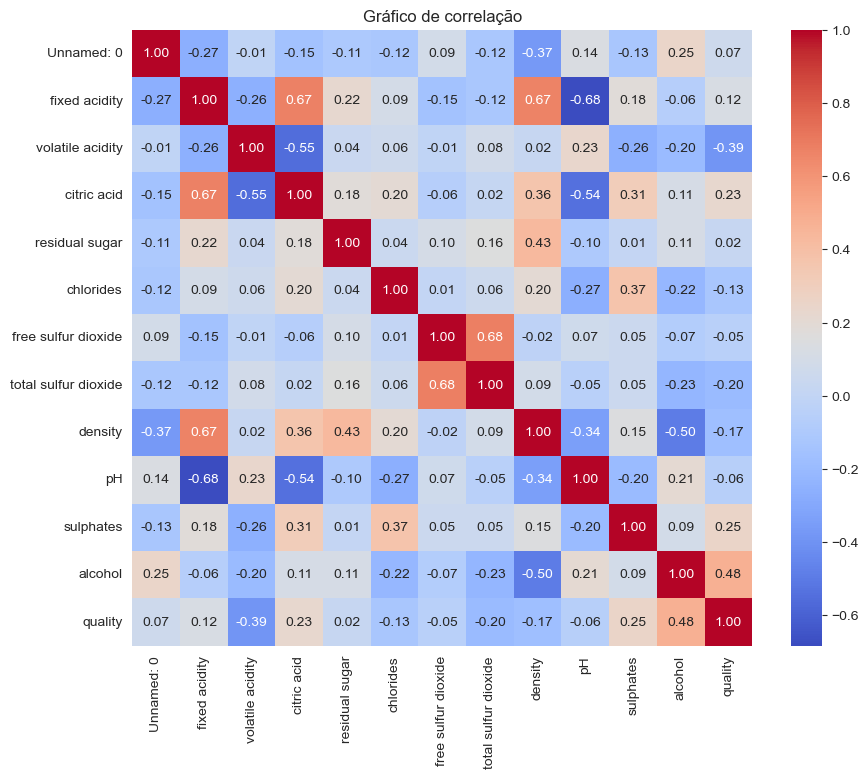

In [35]:
correlacao = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlacao,annot=True,cmap='coolwarm', fmt=".2f")
plt.title('Gráfico de correlação')
plt.show()

In [36]:
df_maior_corr = df[['volatile acidity','citric acid','sulphates', 'alcohol', 'quality']]

df_maior_corr.head(10)

,volatile acidity,citric acid,sulphates,alcohol,quality
0,0.70,0.00,0.56,9.4,5
1,0.88,0.00,0.68,9.8,5
2,0.76,0.04,0.65,9.8,5
3,0.28,0.56,0.58,9.8,6
4,0.70,0.00,0.56,9.4,5
5,0.66,0.00,0.56,9.4,5
6,0.60,0.06,0.46,9.4,5
7,0.65,0.00,0.47,10.0,7
8,0.58,0.02,0.57,9.5,7
9,0.50,0.36,0.80,10.5,5


# 3 - Preparação Final dos Dados

A) Separe a base em X(Features) e Y(Target)

B) Separe a base em treino e teste.


# A

In [37]:
#seu código aqui
#Separando em X e Y 
X = df_maior_corr.drop('quality', axis = 1)
Y = df_maior_corr['quality']

# B

In [38]:
# Separando em treino e teste com uma base de 20% para teste e 80% para treino
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [39]:
# Aplicando o smote para balancear as classes
# Criar uma instância do SMOTE
smote = SMOTE(random_state=42)

# Aplicar o SMOTE aos dados de treinamento (X_train, y_train)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, Y_train)

# Verificar a distribuição das classes após o balanceamento
print("Distribuição das classes após o balanceamento:")
print(Y_train_balanced.value_counts())

Distribuição das classes após o balanceamento:
quality
6    551
5    551
4    551
7    551
8    551
3    551
Name: count, dtype: int64


# 4 - Modelagem

A) Inicie e treine o modelo de Random Forest

B) Aplique a base de teste o modelo.


# A

In [40]:
#seu código aqui
# Iniciando o modelo de random forest
rf_model = RandomForestClassifier(random_state=42)

In [41]:
# Treinando o modelo
rf_model.fit(X_train_balanced, Y_train_balanced)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# B

In [42]:
#Aplicando a base de testes
Y_pred = rf_model.predict(X_test)

# 5 - Avaliação

A) Avalie as principais métricas da Claissificação e traga insights acerca do resultado, interprete os valores achados.

B) Você nota que o modelo teve dificuldade para prever alguma classe? Se sim, acredita que tenha relação com o balanceamento dos dados? Explique.


# A

In [43]:
# Avaliando as principais métricas
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.59
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.08      0.20      0.12        10
           5       0.73      0.65      0.69       130
           6       0.63      0.56      0.59       132
           7       0.57      0.67      0.62        42
           8       0.12      0.20      0.15         5

    accuracy                           0.59       320
   macro avg       0.36      0.38      0.36       320
weighted avg       0.64      0.59      0.61       320

Matriz de Confusão:
 [[ 0  0  1  0  0  0]
 [ 1  2  4  3  0  0]
 [ 5  8 85 30  1  1]
 [ 0 13 26 74 16  3]
 [ 0  1  0 10 28  3]
 [ 0  0  0  0  4  1]]


**Sim, o modelo apresenta dificuldades nítidas para prever as classes das extremidades, como as notas 3, 4 e 8.
Essa dificuldade tem relação direta com o desbalanceamento dos dados. Ao observar a contagem de amostras (usando df['quality'].value_counts()), nota-se que a grande maioria dos vinhos possui notas 5 e 6, enquanto as classes minoritárias possuem pouquíssimos exemplos.**

# B

**Podemos notar que o modelo preve melhor as classes mais frequentes como 5,6 e 7 e possui um desempenho menor nas classes mais raras como 3,4 e 8**

# 6 - Melhorando os Hyperparametros

A) Defina o Grid de parametros que você quer testar

B) Inicie e Treine um novo modelo utilizando o random search.

C) Avalie os resultados do modelo.

D) Você identificou melhorias no modelo após aplicar o random search? Justifique.


ps. Essa parte da atividade demorará um pouco para rodar!

# A

In [44]:
#seu código aqui
# Definindo o grid de parâmetros que eu vou utilizar
param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'max_features':['sqrt','log2'],
}

# B

In [45]:
# Iniciando um novo modelo com o random search
# iniciando o random search
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid,
                                   n_iter=400, cv=5, n_jobs=-1, verbose=2, random_state=42, scoring='accuracy')

In [46]:
# Aplicando o random search as bases de treino
random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,400
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [47]:
# Obtendo os melhores valores para os hyperparametros
best_params = random_search.best_params_
print(f"Melhores Hiperparâmetros: {best_params}")

Melhores Hiperparâmetros: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': True}


In [48]:
# Treinando o modelo agora com os melhores valores para os hyperparametros
best_model = random_search.best_estimator_
best_model.fit(X_train, Y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
# Realizando novas previsões agora com os novos valores de hyperparametros
Y_pred = best_model.predict(X_test)

# C

In [50]:
# Verificando as métricas novamente
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.63
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.67      0.75      0.71       130
           6       0.60      0.62      0.61       132
           7       0.58      0.52      0.55        42
           8       0.00      0.00      0.00         5

    accuracy                           0.63       320
   macro avg       0.31      0.32      0.31       320
weighted avg       0.60      0.63      0.61       320

Matriz de Confusão:
 [[ 0  0  1  0  0  0]
 [ 0  0  6  4  0  0]
 [ 0  1 97 31  1  0]
 [ 0  0 39 82 11  0]
 [ 0  0  1 18 22  1]
 [ 0  0  0  1  4  0]]


C:\Users\Supervisor\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Supervisor\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Supervisor\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# D

**Sim, foram identificadas melhorias após a aplicação do RandomizedSearchCV, embora modestas subindo de 0,59 para 0,63 também houve uma pequena piora no precision da classe 5 mas com melhoras em seu F1-score e recall, também é possivel notar um ganho no recall das classes 6 e 7, indicando que o modelo tornou-se mais sensivel para identificar estas qualidades, reduzindo os falsos negativos**

# 7 - Chegando a perfeição

Baseado em tudo que você já aprendeu até agora, quais outras técnicas você acredita que poderiam ser aplicadas ao modelo para melhorar ainda mais suas previsões?

**Além do  SMOTE que eu apliquei para balancear as classes acredito que o feature engineering é o próximo passo crucial **